In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold

In [2]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [3]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = 0.0 * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=None,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [ ]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=0.0,#1e2,
                                   R_outer_ratio=20,)

q0 = global_sys.q0

# Compute initial L, M(q0), f
L, M, f = global_sys.assemble_global_LMf(q0)

# Time vector
N_t:int=30000
t_vec = None
if t_vec is None:
  t1 = 3e10
  t2 = 0.5e12
  # Define vector of t points for both timescales
  # t_vec = np.array([*np.linspace(0, t1, N_t+1), *np.linspace(t1, t2, N_t+1)[1:]])
  t_vec = np.linspace(0, t1, N_t)


In [5]:
# Set mass rate for injection
mdot_inj = 3.0
# Add source term for injection
f_inj = 0.0 * f
f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj

In [ ]:
/

In [10]:
# Post-process with output size (n_t, n_chambers, (N_r))
m, p, sigmas, u = global_sys.post_process(t_vec, q_out)

Time index 4. Chambers are in a 2D plane. 
Time index 25. Chambers are in a 2D plane. 
Time index 300. Chambers are in a 2D plane. 
Time index 1500. Chambers are in a 2D plane. 


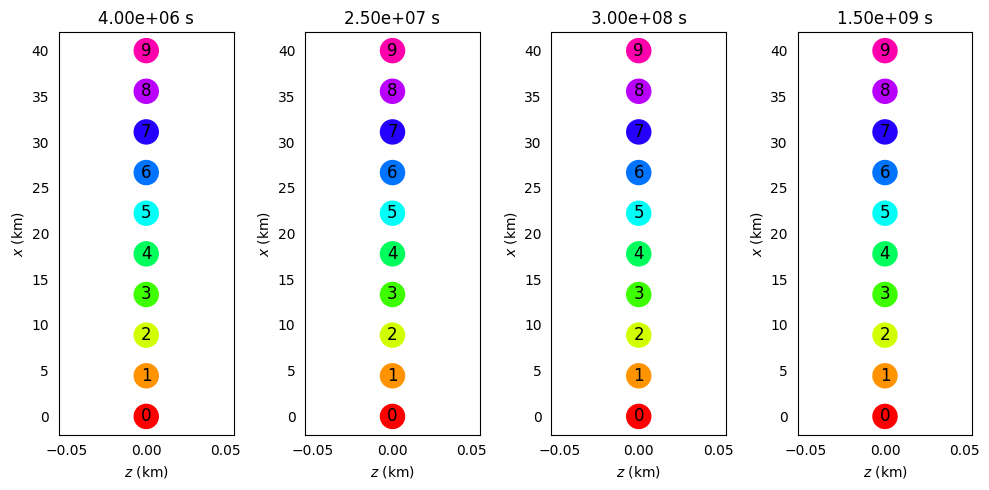

In [ ]:
t_select_index = 0

fig, ax = plt.subplots(1, 4, figsize=(10,5), dpi=100)
index_array = (t_vec.size * np.array([0.01, 0.1, 0.5, 0.9])).astype(int)
for i, t_select_index in enumerate(index_array):
  global_sys.show_network(q_out[t_select_index,:], ax=ax[i], node_scale=300)
  print(f"Time index {t_select_index}. Chambers are in a 2D plane. ")
  ax[i].set_title(f"{t_vec[t_select_index]:.2e} s")
fig.set_tight_layout(True)

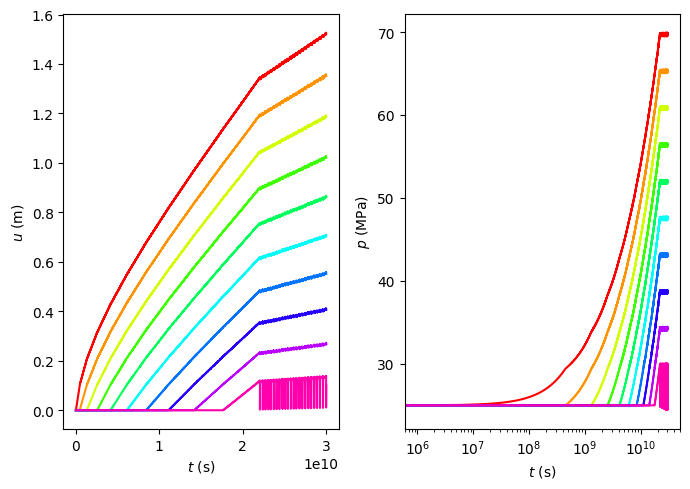

In [12]:
''' Wall displacement, pressure in each chamber '''
fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=100)
cmap = matplotlib.cm.hsv
colors = cmap(np.linspace(0,1,global_sys.num_blocks,endpoint=False))

for i in range(p.shape[1]):
  ax[0].plot(t_vec, u[:,i,0], color=colors[i])
ax[0].set_xlabel("$t$ (s)")
ax[0].set_ylabel("$u$ (m)")

for i in range(p.shape[1]):
  ax[1].semilogx(t_vec, p[:,i] / 1e6, color=colors[i])
ax[1].set_xlabel("$t$ (s)")
ax[1].set_ylabel("$p$ (MPa)")

fig.tight_layout()

(22000000000.0, 23000000000.0)

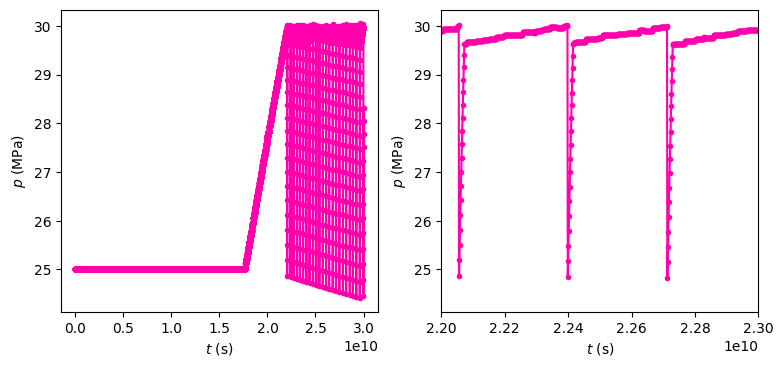

In [29]:

plt.figure(figsize=(9,4),dpi=100)

plt.subplot(1,2,1)
plt.plot(t_vec, p[:,-1] / 1e6, '.-', color=colors[i])
plt.xlabel("$t$ (s)")
plt.ylabel("$p$ (MPa)")

plt.subplot(1,2,2)

plt.plot(t_vec, p[:,-1] / 1e6, '.-', color=colors[i])
plt.xlabel("$t$ (s)")
plt.ylabel("$p$ (MPa)")
plt.xlim(2.2e10, 2.3e10)

In [ ]:
# Estiamte dpdt
t_cell = 0.5 * (t_vec[:-1] + t_vec[1:])
dt_vec = t_vec[1:] - t_vec[:-1]
dpdt = np.diff(p[:,-1]) / 

In [15]:
z_sample_mesh = np.linspace(0, z_scale, 20)
mdot_grid = np.zeros((q_out.shape[0], z_sample_mesh.size))

def eval_mdot_contribution(tup, z):
  ''' Evaluate contribution to mass rate of a particular pairwise flow at location x.
  Input:
    tup: tuple containing (z_0, z_1, and mdot from chamber 0 to chamber 1 )
    z: depth to evaluate at '''
  # Check whether z is between z_0 and z_1
  z_min = 0.5 * (tup[0] + tup[1]) - 0.5 * np.abs(tup[1] - tup[0])
  z_max = 0.5 * (tup[0] + tup[1]) + 0.5 * np.abs(tup[1] - tup[0])
  if z <= z_max and z >= z_min:
    # Evaluate sign modification based on geometry
    sign = np.sign(tup[1] - tup[0])
    return sign * tup[2]
  else:
    return 0.0

def mdot_total(tups, z):
  mdot = np.zeros_like(z, dtype=float)
  for i, z_i in enumerate(z):
    mdot[i] = sum([eval_mdot_contribution(tup, z_i) for tup in tups])
  return mdot

for time_idx in range(q_out.shape[0]):
  # Extract global state vector
  q = q_out[time_idx,:]
  # Compute pressure of each node
  p_node = global_sys.pressure(q)

  # Assemble of triples (z_1, z_2, mdot) characterizing transport in the z-direction
  transports = []
  for i in range(global_sys.num_blocks):
    node_i = global_sys.nodes[i]
    for j in range(i+1, global_sys.num_blocks):
      node_j = global_sys.nodes[j]

      # Compute distance
      dist = float(np.sqrt((node_i.x - node_j.x) ** 2
                    + (node_i.y - node_j.y) ** 2
                    + (node_i.z - node_j.z) ** 2))
      # Compute average pressure gradient
      dpdx = (p_node[i] - p_node[j]) / dist
      # Factor between (0, 1) that modulates flow between the two chambers
      threshold_factor = float(cnetwork.smoother(np.abs(dpdx) - global_sys.dpdx_crit,
                                  global_sys.dpdx_threshold_scale))
      if threshold_factor > 1 or threshold_factor < 0:
        raise ValueError
      if threshold_factor > 1e-15:
        # Compute flow admittance ( (m/s) / Pa ) -- sign is determined automatically by multiplication with state vector q
        Y = threshold_factor * global_sys.r_hydr * global_sys.r_hydr / 16.0 / global_sys.mu0 / dist
        # Multiply mass rate coefficient (kg / s) by dimensionless flow matrix M_loc
        M_loc = (Y * global_sys.rho0 * global_sys.K_f) * global_sys.M_stencils[(i,j,)]
      else:
        M_loc = 0.0 * global_sys.M_stencils[(i,j,)]

      ind_m_i = i*global_sys.block_size + 2*global_sys.Nr
      ind_m_j = j*global_sys.block_size + 2*global_sys.Nr

      # if np.abs((M_loc @ q)[ind_m_j]) > 0:
        # Print pairwise mass transfer if nonzero
        # print((M_loc @ q)[ind_m_i], (M_loc @ q)[ind_m_j])
      mdot_i = float((M_loc @ q)[ind_m_i])
      if mdot_i*mdot_i > 0:
        transports.append((node_i.z, node_j.z, mdot_i,))

  mdot_grid [time_idx,:] = mdot_total(transports, z_sample_mesh)

# plt.plot(mdot_total(transports, z_sample_mesh))
# transports, mdot_total(transports, z_sample_mesh)

Shown: mass transfer timescale
Deviatoric Maxwell time = 5.000000e+10 s


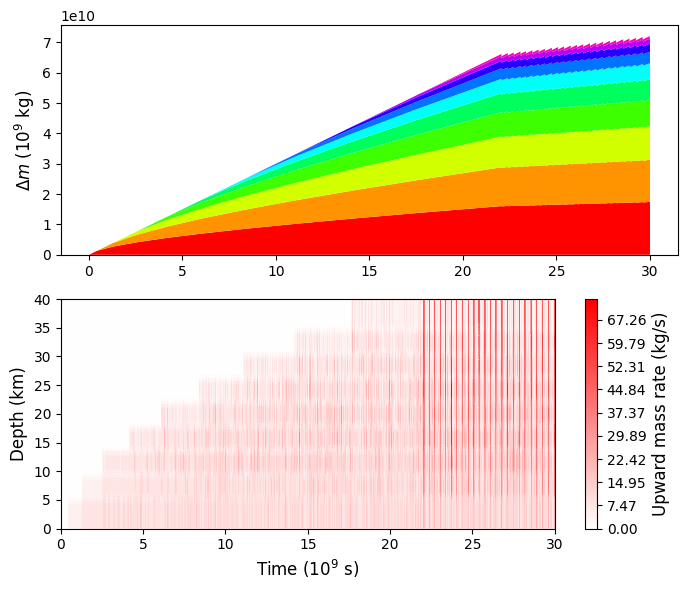

In [16]:
fig, ax = plt.subplots(2, 1,figsize=(7,6),dpi=100,)

# Delta mass, lifted to zero
polys = ax[0].stackplot(t_vec/1e9, m.T - m.T.min(axis=1, keepdims=True), colors=colors)
# plt.gca().set_xscale("log")
# fig.tight_layout()
# ax[0].set_xlabel("Time ($10^9$ s)", fontsize=12)
ax[0].set_ylabel("$\Delta m$ ($10^9$ kg)", fontsize=12)
# ax[0].set_xlim(0, 1.25)

# Compute clipping interval for the colorbar
# cl = (mdot_grid.min(), mdot_grid.max())
# if cl[0] >= 0:
#   cinterval = (0.5, 1.0) # Use full range but the correct color tone
# elif cl[1] <= 0:
#   cinterval = (0.0, 0.5) # Use full range but the correct color tone
# elif 0.5 * (cl[0] + cl[1]) > 0:
#   cinterval = (0.5 * (1 + cl[0] / cl[1]), 1)
# else:
#   cinterval = (0.0, 0.5 * (1 - cl[1] / cl[0]))
# # Shifted diverging cmap
# shift_div_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
#     f'trunc(bwr,{cinterval[0]},{cinterval[1]})',
#     matplotlib.cm.bwr(np.linspace(cinterval[0], cinterval[1], 1000)))

clim = (mdot_grid.min(), mdot_grid.max(),)
shift_div_cmap = cnetwork.zero_aligned_cmap(clim)

if clim[1] - clim[0] ==0 :
  print("Data values are all zero. Skipping mass rate spatial plot.")

else:
  plt.sca(ax[1])

  mg_t, mg_z = np.meshgrid(t_vec, z_sample_mesh)
  plt.contourf(mg_t/1e9, mg_z/1e3, mdot_grid.T, cmap=shift_div_cmap, levels=np.linspace(clim[0], clim[1], 100))
  cb = plt.colorbar()#, ax=ax[:])
  cb.set_label("Upward mass rate (kg/s)", fontsize=12)
  plt.xlabel("Time ($10^9$ s)", fontsize=12)
  plt.ylabel("Depth (km)", fontsize=12)

  fig.tight_layout()

  print("Shown: mass transfer timescale")
  print(f"Deviatoric Maxwell time = {t_d:e} s")